# 05 - Maternal QRS detection

Goal: detect maternal QRS complexes from `S4`, the upsampled abdominal ECG signal.

## Why this step is needed

The maternal ECG is usually much stronger than the fetal ECG in abdominal recordings. Before detecting fetal QRS complexes, we first need to find the maternal QRS positions. Those positions will be used in the next step to estimate and subtract the maternal ECG.

The `.fqrs` annotations in PhysioNet are fetal QRS references, not maternal QRS references. For this maternal step, we therefore use visual checks and physiological plausibility.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import data_io
import preprocessing
import qrs_detection
import plotting

# Reload local modules so Jupyter picks up code changes during development.
importlib.reload(data_io)
importlib.reload(preprocessing)
importlib.reload(qrs_detection)
importlib.reload(plotting)

from data_io import load_record
from preprocessing import remove_baseline_wander, remove_powerline_interference, upsample_signals
from qrs_detection import detect_maternal_qrs
from plotting import plot_maternal_qrs_detection, plot_maternal_qrs_on_channels, plot_qrs_template


## Load the record and rebuild S4

`S4` is the output of the previous step. We rebuild it here so this notebook can run independently.

In [2]:
record = load_record('a14')
S1 = record.signals

baseline_result = remove_baseline_wander(
    S1,
    fs=record.fs,
    cutoff_hz=3.0,
    numtaps=1001,
)
S2 = baseline_result.filtered_signals

powerline_result = remove_powerline_interference(
    S2,
    fs=record.fs,
    frequencies_hz=(50.0, 100.0, 150.0),
)
S3 = powerline_result.cleaned_signals

upsampling_result = upsample_signals(
    S3,
    fs=record.fs,
    target_fs=2000.0,
)
S4 = upsampling_result.upsampled_signals
fs_s4 = upsampling_result.target_fs

print(f'Record: {record.name}')
print(f'S4 shape: {S4.shape}')
print(f'S4 sampling frequency: {fs_s4:.0f} Hz')
print(f'S4 duration: {S4.shape[0] / fs_s4:.2f} s')


Record: a14
S4 shape: (120000, 4)
S4 sampling frequency: 2000 Hz
S4 duration: 60.00 s


## Detect maternal QRS complexes

The detector has three main parts:

1. PCA first component: combine the 4 channels into one stronger signal.
2. Maternal QRS template: build an average QRS shape from first-pass candidates.
3. Cross-correlation: find where the signal looks most similar to the template.

In [3]:
mqrs_result = detect_maternal_qrs(
    S4,
    fs=fs_s4,
    max_heart_rate_bpm=140.0,
)
mqrs_samples = mqrs_result.mqrs_samples
mqrs_times = mqrs_samples / fs_s4
duration_s = S4.shape[0] / fs_s4
estimated_hr_bpm = len(mqrs_samples) / duration_s * 60.0
rr_intervals_s = np.diff(mqrs_times)

print(f'Initial QRS candidates: {len(mqrs_result.initial_qrs_samples)}')
print(f'Detected MQRS: {len(mqrs_samples)}')
print(f'Estimated maternal heart rate: {estimated_hr_bpm:.1f} bpm')
if len(rr_intervals_s) > 0:
    print(f'Median RR interval: {np.median(rr_intervals_s):.3f} s')
    print(f'Min/Max RR interval: {np.min(rr_intervals_s):.3f} / {np.max(rr_intervals_s):.3f} s')
print('PCA explained variance ratio:', np.round(mqrs_result.explained_variance_ratio, 3))


Initial QRS candidates: 102
Detected MQRS: 102
Estimated maternal heart rate: 102.0 bpm
Median RR interval: 0.607 s
Min/Max RR interval: 0.476 / 0.636 s
PCA explained variance ratio: [0.651 0.209 0.133 0.007]


## Save detected maternal QRS positions

The detected MQRS positions are saved both as sample indices in `S4` and as seconds. The next notebook can load this file when subtracting the maternal ECG.

In [4]:
results_dir = PROJECT_ROOT / 'results' / 'notebook05'
results_dir.mkdir(parents=True, exist_ok=True)

mqrs_table = pd.DataFrame({
    'sample_s4': mqrs_samples.astype(int),
    'time_s': mqrs_times,
})
mqrs_table_path = results_dir / 'a14_mqrs_detected.csv'
mqrs_table.to_csv(mqrs_table_path, index=False)
mqrs_table.head()


,sample_s4,time_s
0,591,0.2955
1,1844,0.9220
2,3101,1.5505
3,4374,2.1870
4,5635,2.8175


## Detection signals

This plot shows the internal signals used by the detector. The black markers are the final maternal QRS detections.

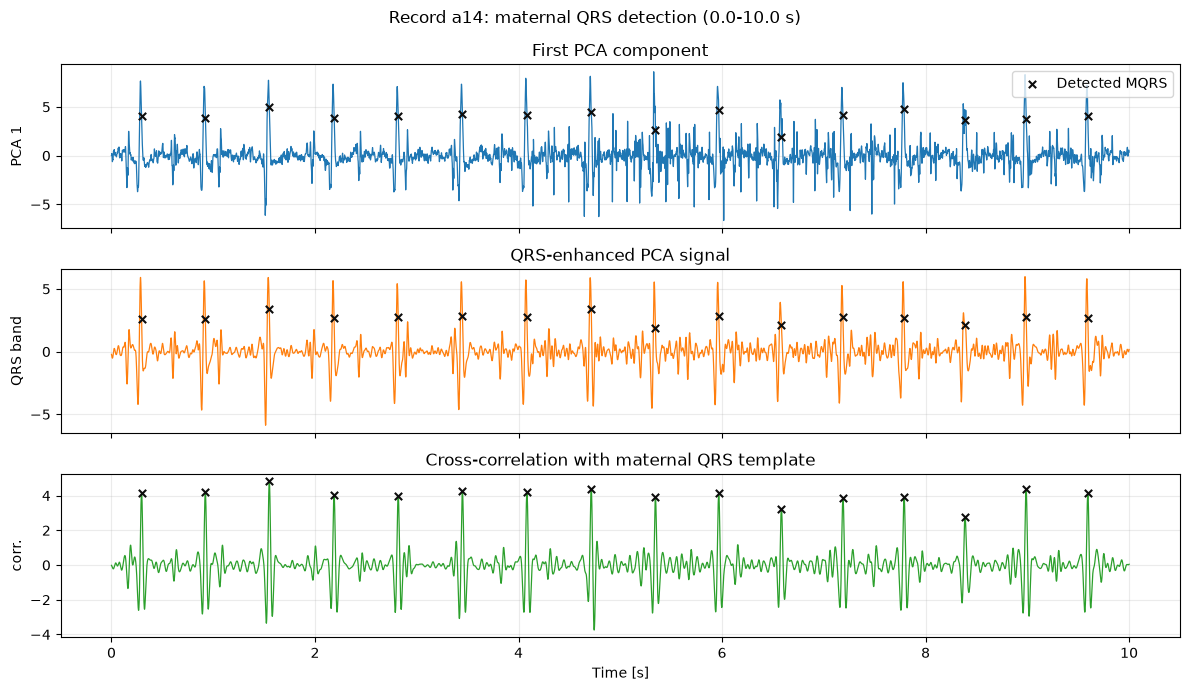

In [5]:
fig, axes = plot_maternal_qrs_detection(
    record.name,
    mqrs_result.pca_signal,
    mqrs_result.qrs_enhanced_signal,
    mqrs_result.correlation_signal,
    mqrs_samples,
    fs=fs_s4,
    seconds=(0, 10),
    save_path=PROJECT_ROOT / 'figures' / 'notebook05' / 'a14_mqrs_detection_0_10s.png',
)
plt.show()


## Maternal QRS template

This is the average maternal QRS shape used by the cross-correlation detector. The vertical dashed line marks the candidate center.

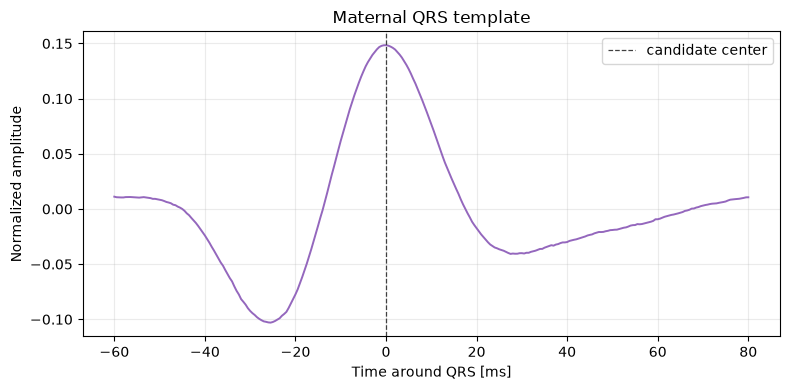

In [6]:
fig, ax = plot_qrs_template(
    mqrs_result.qrs_template,
    fs=fs_s4,
    before_samples=mqrs_result.template_before_samples,
    save_path=PROJECT_ROOT / 'figures' / 'notebook05' / 'a14_mqrs_template.png',
)
plt.show()


## Detected MQRS on the abdominal channels

This plot overlays the detected maternal QRS positions on the four `S4` channels. It is useful for checking that the detections line up with the large maternal ECG peaks.

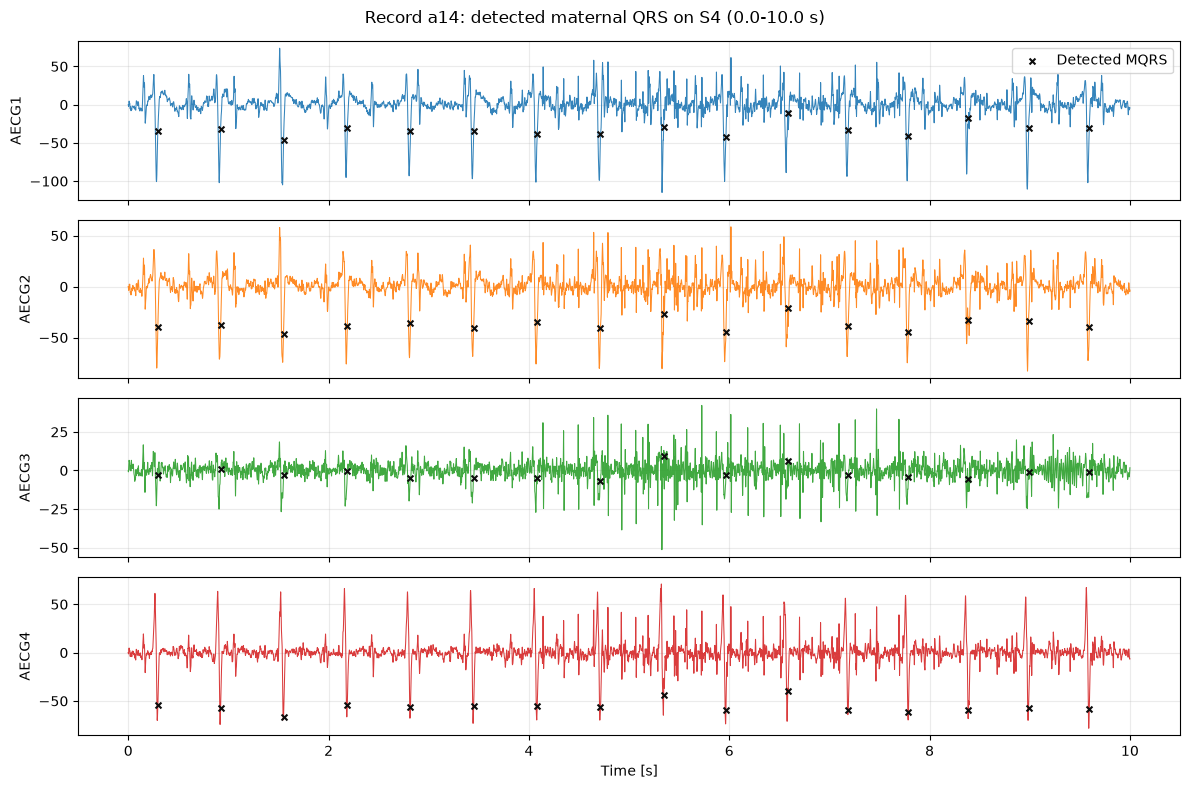

In [7]:
fig, axes = plot_maternal_qrs_on_channels(
    record,
    S4,
    fs=fs_s4,
    mqrs_samples=mqrs_samples,
    seconds=(0, 10),
    save_path=PROJECT_ROOT / 'figures' / 'notebook05' / 'a14_mqrs_on_s4_0_10s.png',
)
plt.show()


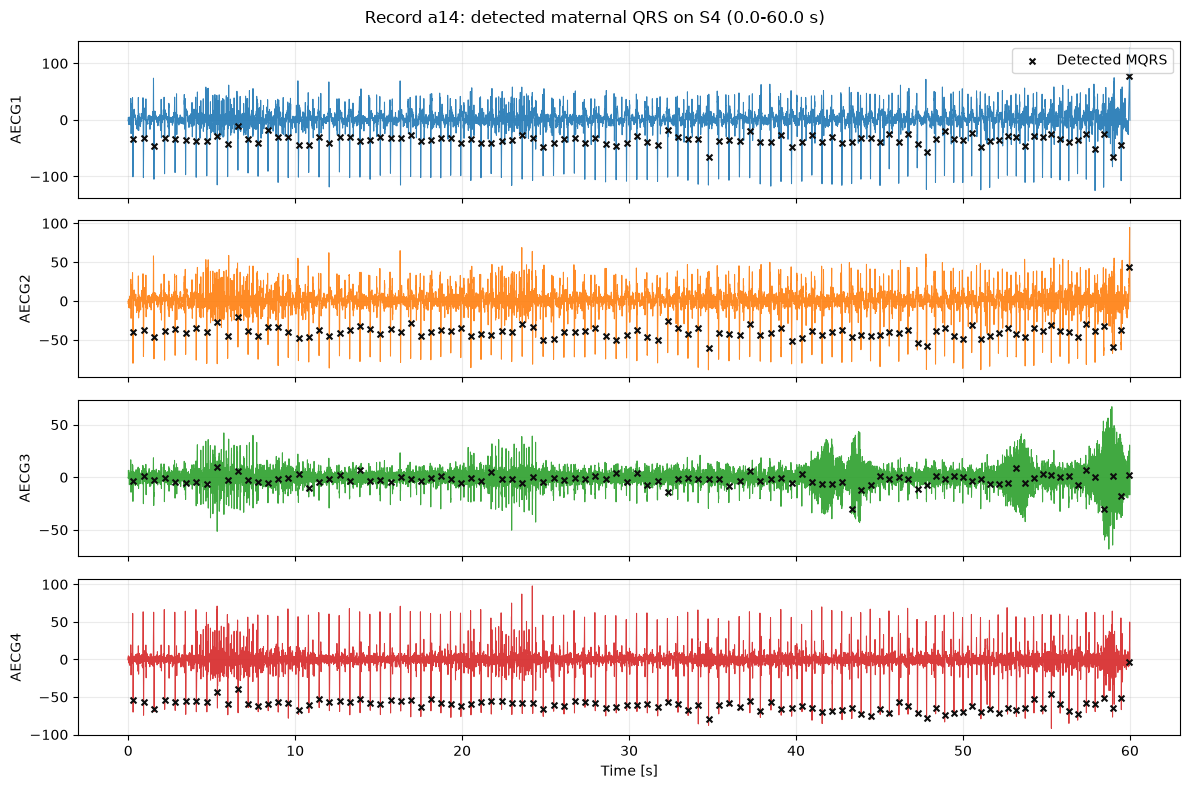

In [8]:
fig, axes = plot_maternal_qrs_on_channels(
    record,
    S4,
    fs=fs_s4,
    mqrs_samples=mqrs_samples,
    seconds=(0, duration_s),
    save_path=PROJECT_ROOT / 'figures' / 'notebook05' / 'a14_mqrs_on_s4_full.png',
)
plt.show()


## Output of this step

The output is the list of maternal QRS positions. For record `a14`, the detector finds about one maternal beat every 0.6 seconds. The next step is maternal ECG cancellation: use these MQRS positions to estimate the maternal ECG waveform and subtract it from `S4`.